<a href="https://colab.research.google.com/github/razankablan/razankablan-data-analysis-exercises/blob/main/Chapter_7_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%writefile stock_analysis.py
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

class StockAnalyzer:
    def __init__(self, ticker, start_date, end_date):
        self.ticker = ticker
        df = yf.download(ticker, start=start_date, end=end_date)

        # In case yfinance returns multi-index columns
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)

        # Ensure Close is a Series (1D)
        if isinstance(df['Close'], pd.DataFrame):
            df['Close'] = df['Close'].squeeze()

        self.data = df.copy()
        self.data['Close'] = pd.to_numeric(self.data['Close'], errors='coerce')
        self.data.dropna(subset=['Close'], inplace=True)

    def support_resistance_levels(self, levels=3, distance=20, prominence=1):
        # Extract closing prices as a pure 1D NumPy array
        close = self.data['Close'].to_numpy().astype(float).flatten()

        # Find resistance (peaks)
        peaks_idx, _ = find_peaks(close, distance=distance, prominence=prominence)
        # Find support (troughs)
        troughs_idx, _ = find_peaks(-close, distance=distance, prominence=prominence)

        close_series = pd.Series(close, index=self.data.index)
        peaks = close_series.iloc[peaks_idx].sort_values(ascending=False)
        troughs = close_series.iloc[troughs_idx].sort_values()

        resistances = peaks.head(levels).values
        supports = troughs.head(levels).values
        return supports, resistances

    def plot_support_resistance(self, supports, resistances):
        plt.figure(figsize=(12,6))
        plt.plot(self.data.index, self.data['Close'], label=f'{self.ticker} Close', color='blue')

        for i, s in enumerate(supports, 1):
            plt.axhline(y=s, color='green', linestyle='--', label=f'Support {i}: {s:.2f}')
        for i, r in enumerate(resistances, 1):
            plt.axhline(y=r, color='red', linestyle='--', label=f'Resistance {i}: {r:.2f}')

        plt.title(f"{self.ticker} Support and Resistance Levels (2017–2018)")
        plt.xlabel("Date")
        plt.ylabel("Price (USD)")
        plt.legend()
        plt.show()


Overwriting stock_analysis.py


In [ ]:
from importlib import reload
import stock_analysis
reload(stock_analysis)
from stock_analysis import StockAnalyzer


/content/stock_analysis.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Support Levels: [129.17999268 139.13999939 139.75999451]
Resistance Levels: [418.97000122 381.42999268 370.98001099]


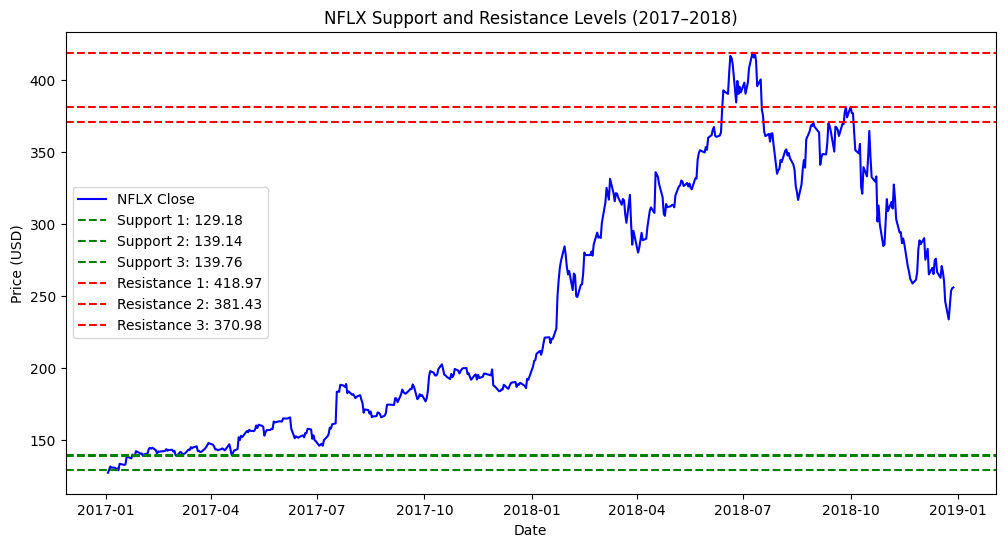

In [ ]:
analyzer = StockAnalyzer("NFLX", "2017-01-01", "2018-12-31")
supports, resistances = analyzer.support_resistance_levels(levels=3)

print("Support Levels:", supports)
print("Resistance Levels:", resistances)

analyzer.plot_support_resistance(supports, resistances)


In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

class StockVisualizer:
    def __init__(self):
        pass

    def after_hours_effect(self, ticker, start, end):
        # Download daily data
        data = yf.download(ticker, start=start, end=end)

        # Flatten columns in case of MultiIndex (Adj Close etc.)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        # Make sure Open and Close are Series
        data['Open'] = pd.to_numeric(data['Open'], errors='coerce')
        data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
        data = data.dropna(subset=['Open', 'Close'])

        # Compute previous close and after-hours change
        data['Prev Close'] = data['Close'].shift(1)
        data['After Hours Change'] = data['Open'] - data['Prev Close']

        # Drop first row (NaN)
        data = data.dropna(subset=['After Hours Change'])

        # Plot
        plt.figure(figsize=(12,6))
        plt.plot(data.index, data['After Hours Change'], label='After-hours price change', color='purple')
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.title(f'After-Hours Trading Effect for {ticker} ({start} - {end})')
        plt.xlabel('Date')
        plt.ylabel('Price Change ($)')
        plt.legend()
        plt.grid(True)
        plt.show()


/tmp/ipython-input-3519316933.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Showing after-hours trading effect for META...


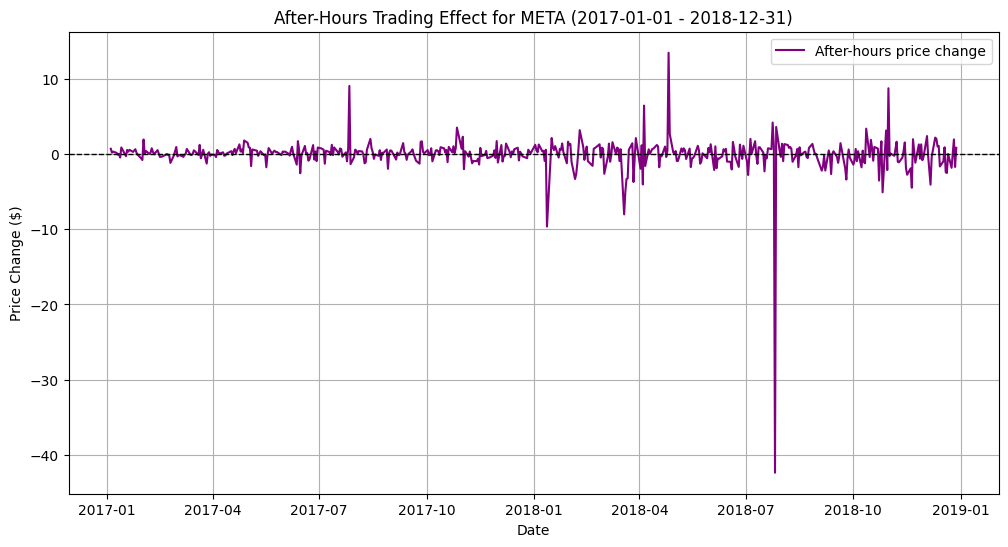


Showing after-hours trading effect for AAPL...


/tmp/ipython-input-3519316933.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


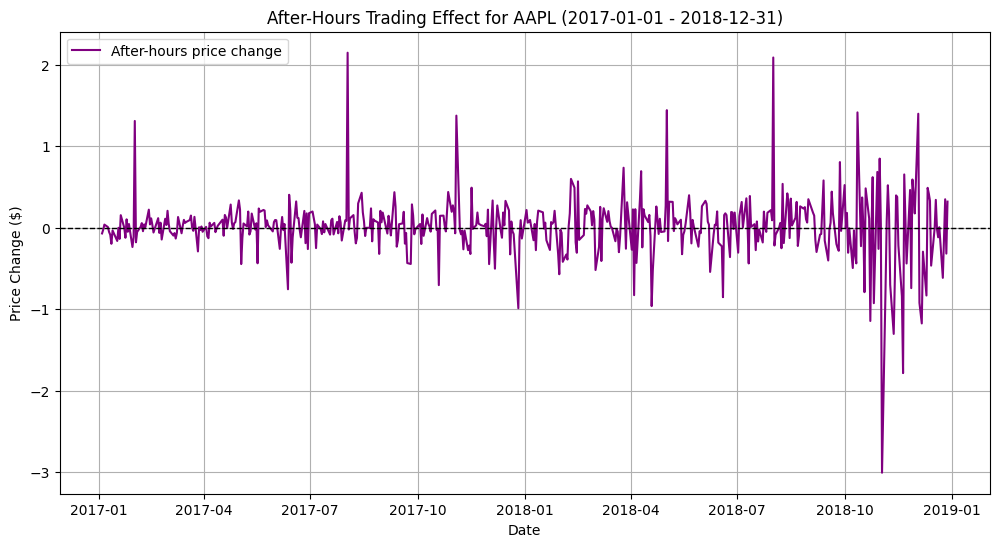

/tmp/ipython-input-3519316933.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Showing after-hours trading effect for AMZN...


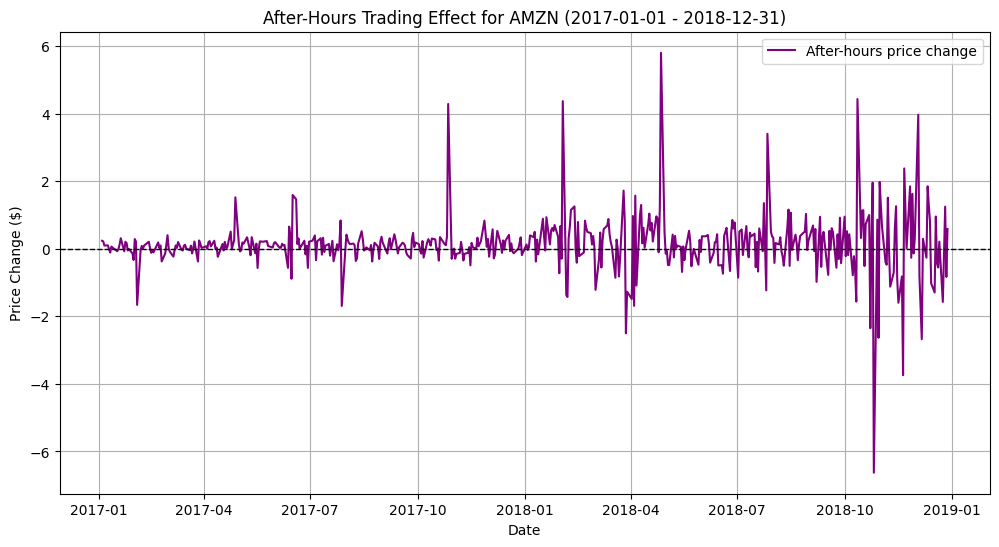

/tmp/ipython-input-3519316933.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Showing after-hours trading effect for NFLX...


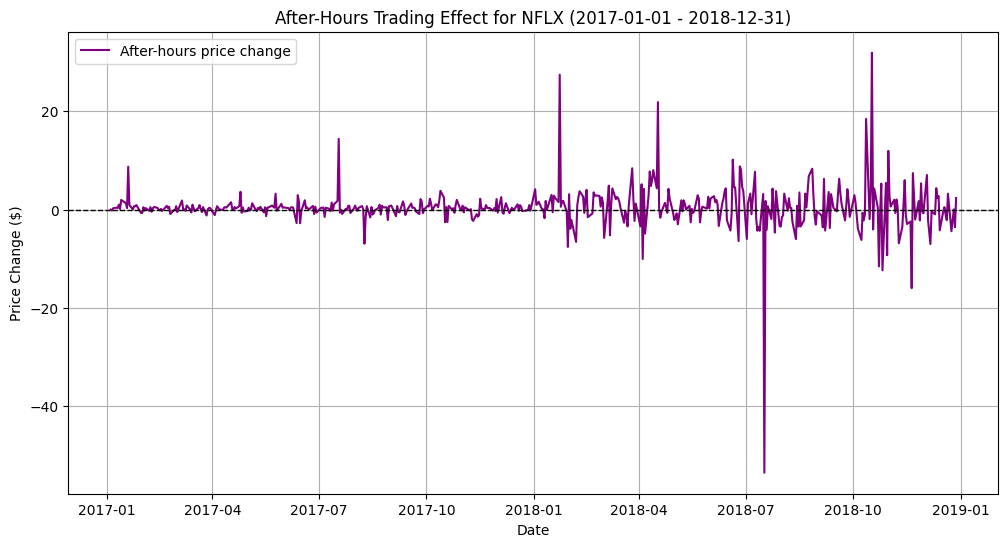

/tmp/ipython-input-3519316933.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Showing after-hours trading effect for GOOG...


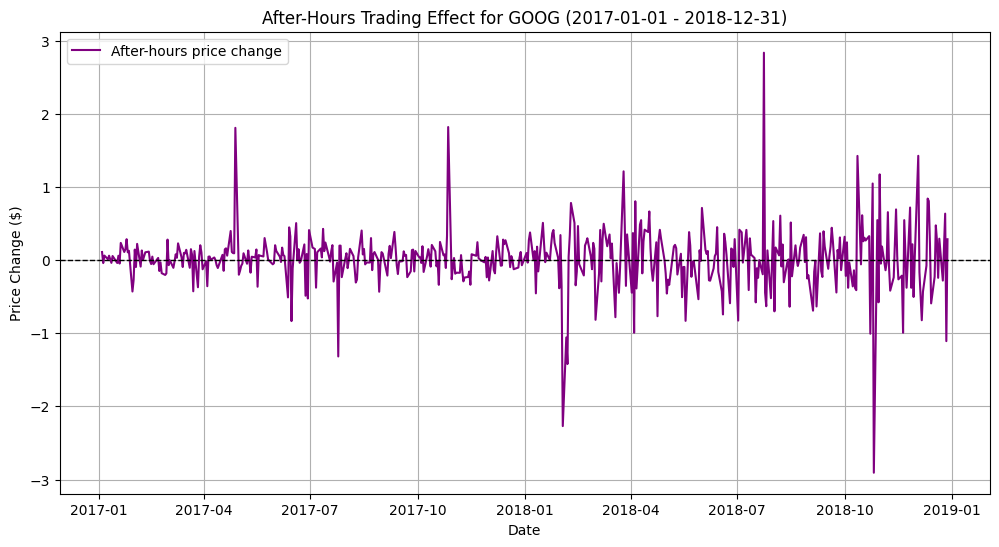

In [ ]:
vis = StockVisualizer()
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
start_date = "2017-01-01"
end_date = "2018-12-31"

for ticker in tickers:
    print(f"\nShowing after-hours trading effect for {ticker}...")
    vis.after_hours_effect(ticker, start_date, end_date)


In [ ]:
import yfinance as yf
import pandas as pd

def make_portfolio(tickers, start, end, weights=None):
    """
    Creates an equal-weighted portfolio of given tickers
    Returns a DataFrame with portfolio Open, Close, Prev Close, After Hours Change
    """
    data = pd.DataFrame()

    for ticker in tickers:
        df = yf.download(ticker, start=start, end=end)[['Open','Close']]
        # Flatten columns in case of MultiIndex
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
        df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
        df = df.dropna(subset=['Open','Close'])
        df = df.rename(columns={'Open': f'{ticker}_Open', 'Close': f'{ticker}_Close'})
        if data.empty:
            data = df
        else:
            data = data.join(df, how='inner')

    # Set equal weights if none provided
    if weights is None:
        weights = [1/len(tickers)]*len(tickers)

    # Compute portfolio Open and Close as weighted sum
    data['Portfolio_Open'] = sum(data[f'{t}_Open']*w for t,w in zip(tickers, weights))
    data['Portfolio_Close'] = sum(data[f'{t}_Close']*w for t,w in zip(tickers, weights))

    # Compute previous close and after-hours change for portfolio
    data['Prev Close'] = data['Portfolio_Close'].shift(1)
    data['After Hours Change'] = data['Portfolio_Open'] - data['Prev Close']
    data = data.dropna(subset=['After Hours Change'])

    return data[['Portfolio_Open','Portfolio_Close','Prev Close','After Hours Change']]


In [ ]:
import matplotlib.pyplot as plt

class PortfolioVisualizer:
    def __init__(self):
        pass

    def after_hours_portfolio_effect(self, portfolio_data):
        plt.figure(figsize=(12,6))
        plt.plot(portfolio_data.index, portfolio_data['After Hours Change'],
                 color='orange', label='Portfolio After-Hours Change')
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.title("FAANG Portfolio After-Hours Trading Effect")
        plt.xlabel("Date")
        plt.ylabel("Price Change ($)")
        plt.legend()
        plt.grid(True)
        plt.show()


/tmp/ipython-input-1541340503.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1541340503.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1541340503.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1541340503.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 comple

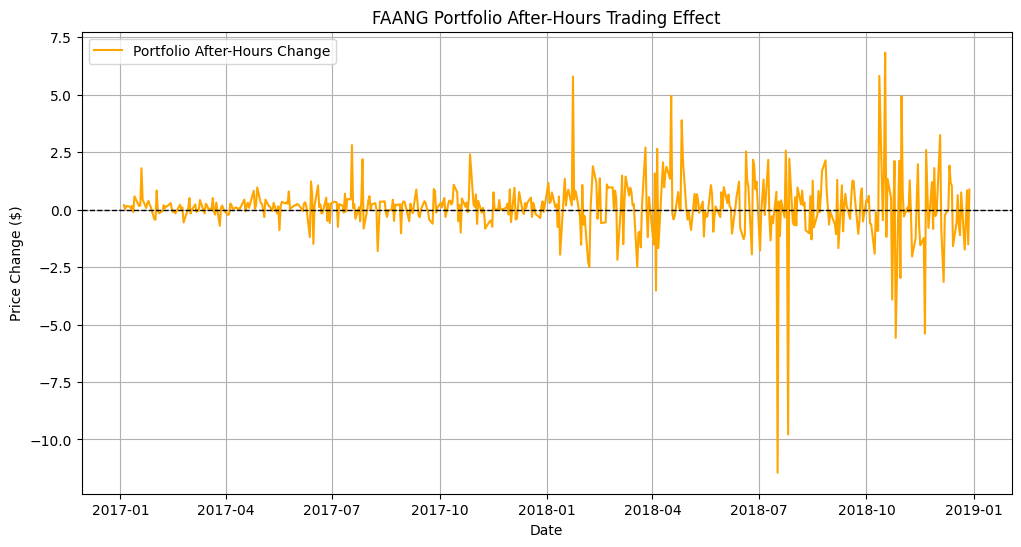

In [ ]:
tickers = ["META","AAPL","AMZN","NFLX","GOOG"]
start_date = "2017-01-01"
end_date = "2018-12-31"

# Create portfolio
faang_portfolio = make_portfolio(tickers, start_date, end_date)

# Visualize
pv = PortfolioVisualizer()
pv.after_hours_portfolio_effect(faang_portfolio)


In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

def open_to_close_portfolio(tickers, start, end, weights=None, title="Portfolio Open-to-Close"):
    """
    Plots the open-to-close area for a portfolio of tickers.
    Green area = price increased from open to close
    Red area = price decreased from open to close
    """
    data = pd.DataFrame()

    for ticker in tickers:
        df = yf.download(ticker, start=start, end=end)[['Open','Close']]
        # Flatten columns in case of MultiIndex
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
        df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
        df = df.dropna(subset=['Open','Close'])
        df = df.rename(columns={'Open': f'{ticker}_Open', 'Close': f'{ticker}_Close'})
        if data.empty:
            data = df
        else:
            data = data.join(df, how='inner')

    # Equal weights if not provided
    if weights is None:
        weights = [1/len(tickers)]*len(tickers)

    # Portfolio Open and Close
    data['Portfolio_Open'] = sum(data[f'{t}_Open']*w for t,w in zip(tickers, weights))
    data['Portfolio_Close'] = sum(data[f'{t}_Close']*w for t,w in zip(tickers, weights))

    # Plot area between open and close
    plt.figure(figsize=(14,6))

    increase = data['Portfolio_Close'] >= data['Portfolio_Open']
    decrease = data['Portfolio_Close'] < data['Portfolio_Open']

    plt.fill_between(data.index, data['Portfolio_Open'], data['Portfolio_Close'],
                     where=increase, color='green', alpha=0.5, label='Price Increase')
    plt.fill_between(data.index, data['Portfolio_Open'], data['Portfolio_Close'],
                     where=decrease, color='red', alpha=0.5, label='Price Decrease')

    plt.plot(data.index, data['Portfolio_Close'], color='blue', label='Close Price')
    plt.plot(data.index, data['Portfolio_Open'], color='black', linestyle='--', label='Open Price')

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Portfolio Price ($)")
    plt.legend()
    plt.grid(True)
    plt.show()


/tmp/ipython-input-1235312127.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1235312127.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1235312127.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1235312127.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 comple

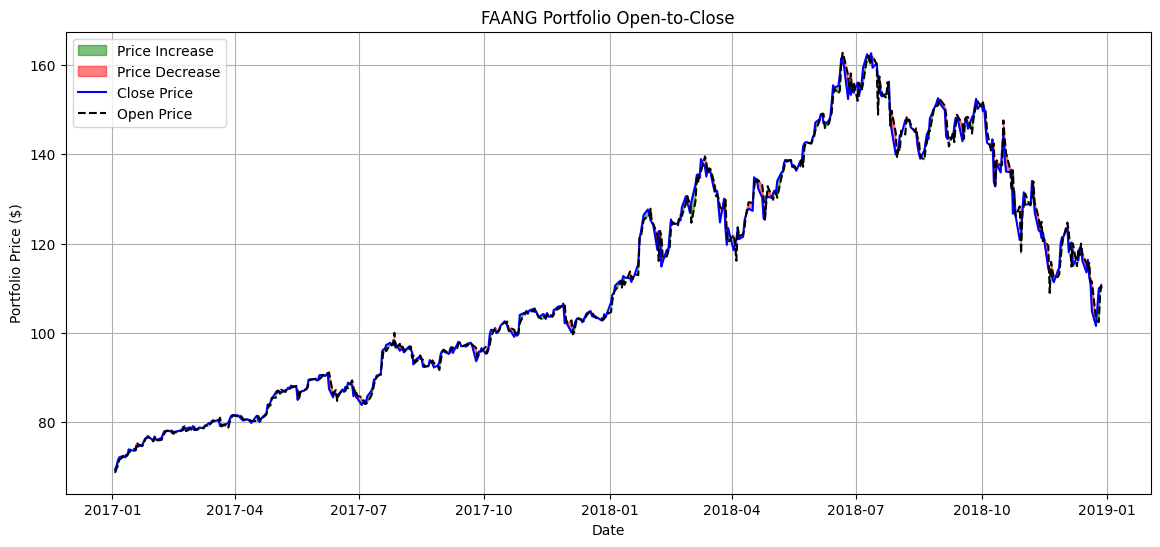

In [ ]:
faang_tickers = ["META","AAPL","AMZN","NFLX","GOOG"]
start_date = "2017-01-01"
end_date = "2018-12-31"

open_to_close_portfolio(faang_tickers, start_date, end_date, title="FAANG Portfolio Open-to-Close")


/tmp/ipython-input-1235312127.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1235312127.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)[['Open','Close']]
[*********************100%***********************]  1 of 1 completed


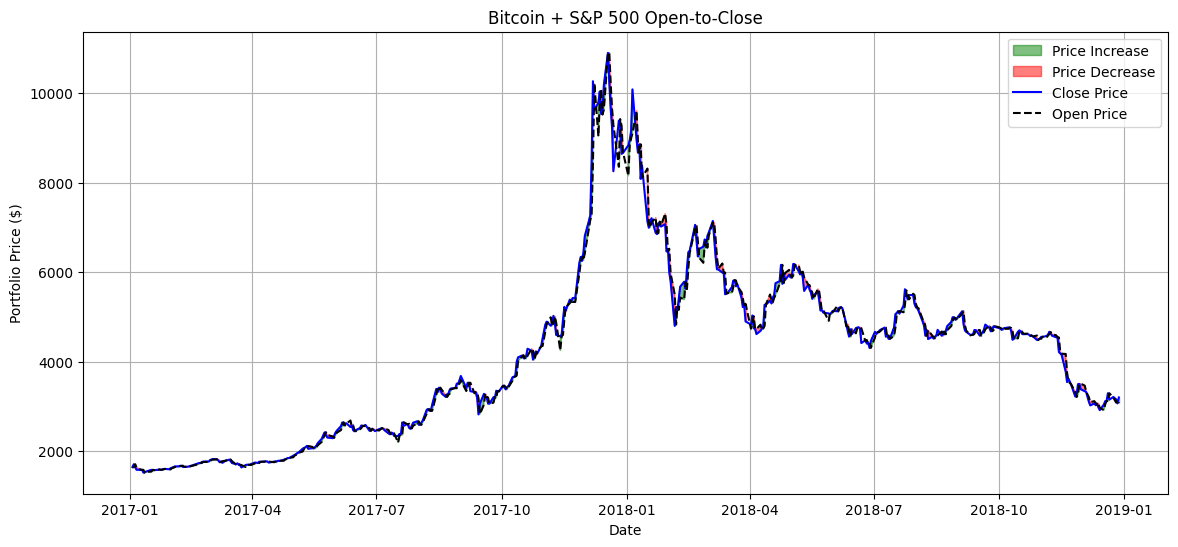

In [ ]:
crypto_sp500 = ["BTC-USD", "^GSPC"]  # S&P 500 ticker: ^GSPC
open_to_close_portfolio(crypto_sp500, start_date, end_date, title="Bitcoin + S&P 500 Open-to-Close")


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Tickers
etf_ticker = "SPY"
top_stocks = ["AAPL", "MSFT", "AMZN"]
tickers = [etf_ticker] + top_stocks

start_date = "2017-01-01"
end_date = "2018-12-31"

# Download data
data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Drop rows with any missing values
data = data.dropna()
data.head()


/tmp/ipython-input-1667679366.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,MSFT,SPY
Date,,,,
2017-01-03,26.796835,37.683498,56.404690,195.575119
2017-01-04,26.766851,37.859001,56.152309,196.738663
2017-01-05,26.902960,39.022499,56.152309,196.582367
2017-01-06,27.202885,39.799500,56.639027,197.285751
2017-01-09,27.452049,39.846001,56.458767,196.634445


In [ ]:
# Daily returns
returns = data.pct_change().dropna()

# Annualized volatility
annualized_vol = returns.std() * np.sqrt(252)
print("Annualized Volatility (2017-2018):")
print(annualized_vol)


Annualized Volatility (2017-2018):
Ticker
AAPL    0.238866
AMZN    0.295359
MSFT    0.225702
SPY     0.129656
dtype: float64


In [ ]:
class AssetGroupAnalyzer:
    def __init__(self, price_data):
        self.data = price_data
        self.returns = price_data.pct_change().dropna()

    def annualized_volatility(self):
        return self.returns.std() * np.sqrt(252)

    def summary(self):
        vols = self.annualized_volatility()
        summary_df = pd.DataFrame({
            'Asset': vols.index,
            'Annualized Volatility': vols.values
        })
        return summary_df.sort_values('Annualized Volatility', ascending=False)


In [ ]:
analyzer = AssetGroupAnalyzer(data)
summary = analyzer.summary()
print(summary)


  Asset  Annualized Volatility
1  AMZN               0.295359
0  AAPL               0.238866
2  MSFT               0.225702
3   SPY               0.129656


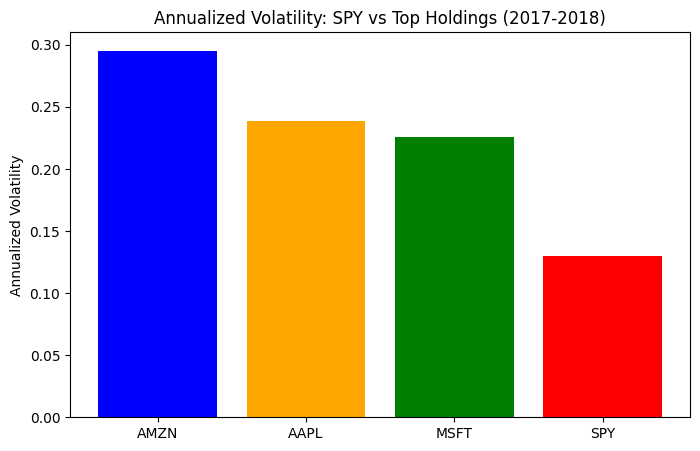

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(summary['Asset'], summary['Annualized Volatility'], color=['blue','orange','green','red'])
plt.title('Annualized Volatility: SPY vs Top Holdings (2017-2018)')
plt.ylabel('Annualized Volatility')
plt.show()


In [ ]:
class StockAnalyzer:
    def __init__(self, ticker, start, end):
        self.ticker = ticker
        self.data = yf.download(ticker, start=start, end=end)['Close'].dropna()
        self.returns = self.data.pct_change().dropna()

    def alpha(self):
        return self.returns.mean() * 252

    def beta(self):
        spy = yf.download('SPY', start=self.data.index[0], end=self.data.index[-1])['Close'].pct_change().dropna()
        common_index = self.returns.index.intersection(spy.index)
        returns_aligned = self.returns.loc[common_index]
        spy_aligned = spy.loc[common_index]
        if len(returns_aligned) < 2 or np.var(spy_aligned) == 0:
            return np.nan
        return np.cov(returns_aligned, spy_aligned)[0,1] / np.var(spy_aligned)

    def annualized_volatility(self):
        return self.returns.std() * np.sqrt(252)

    def is_bear_market(self):
        cum_ret = (1 + self.returns).cumprod()
        drawdown = 1 - cum_ret / cum_ret.cummax()
        return drawdown.max() > 0.2

    def is_bull_market(self):
        cum_ret = (1 + self.returns).cumprod()
        return cum_ret.iloc[-1] > 1.5


In [ ]:
def analyze_stock(ticker, start, end):
    analyzer = StockAnalyzer(ticker, start, end)
    methods = ['alpha', 'beta', 'annualized_volatility', 'is_bear_market', 'is_bull_market']
    results = {m: getattr(analyzer, m)() for m in methods}
    return pd.DataFrame([results])

df = analyze_stock("AAPL", "2017-01-01", "2018-12-31")
print(df)


/tmp/ipython-input-2097596315.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(ticker, start=start, end=end)['Close'].dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2097596315.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start=self.data.index[0], end=self.data.index[-1])['Close'].pct_change().dropna()
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
def analyze_stock(ticker, start, end):
    analyzer = StockAnalyzer(ticker, start, end)

    # List of method names to call
    methods = ['alpha', 'beta', 'annualized_volatility', 'is_bear_market', 'is_bull_market']

    # Call each method dynamically
    results = {m: getattr(analyzer, m)() for m in methods}

    # Return single-row DataFrame
    return pd.DataFrame([results])


In [ ]:
df = analyze_stock("AAPL", "2017-01-01", "2018-12-31")
print(df)


/tmp/ipython-input-2458520093.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(ticker, start=start, end=end)['Close'].dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2458520093.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start=self.data.index[0], end=self.data.index[-1])['Close'].pct_change().dropna()
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2458520093.py:19: RuntimeWarning: Degrees of freedom <= 0 for slice
  return np.cov(self.returns, spy)[0,1] / np.var(spy)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.tru

KeyError: -1